# Phase 2 — Data Preprocessing & Feature Engineering
**AgroSense AI Pipeline**

Goals:
- Handle outliers (IQR capping)
- Encode labels
- Scale features (StandardScaler + MinMaxScaler comparison)
- Engineer new features (NPK ratio, climate stress index)
- Train/validation/test split
- Save final processed bundle

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})

with open('processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

df       = data['df'].copy()
FEATURES = data['features']
print(f'Loaded {len(df)} records, {len(FEATURES)} features.')

Loaded 2200 records, 7 features.


## 2.1  Outlier Capping (IQR)

In [2]:
df_clean = df.copy()
outlier_report = []

for feat in FEATURES:
    Q1, Q3 = df_clean[feat].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_before = ((df_clean[feat] < lo) | (df_clean[feat] > hi)).sum()
    df_clean[feat] = df_clean[feat].clip(lo, hi)
    outlier_report.append({'Feature': feat, 'Capped': n_before, 'Lower': round(lo,2), 'Upper': round(hi,2)})

pd.DataFrame(outlier_report)

,Feature,Capped,Lower,Upper
0,n,0,-73.88,179.12
1,p,138,-32.00,128.00
2,k,200,-23.50,92.50
3,temperature,86,14.08,37.25
4,humidity,30,15.73,134.48
5,ph,57,4.54,8.35
6,rainfall,100,-25.02,213.84


## 2.2  Feature Engineering

In [3]:
# NPK balance ratio
df_clean['npk_total']  = df_clean['n'] + df_clean['p'] + df_clean['k']
df_clean['n_ratio']    = df_clean['n'] / (df_clean['npk_total'] + 1e-6)
df_clean['p_ratio']    = df_clean['p'] / (df_clean['npk_total'] + 1e-6)

# Climate stress index: high temp + low humidity + low rainfall
df_clean['climate_stress'] = (
    (df_clean['temperature'] - df_clean['temperature'].min()) /
    (df_clean['temperature'].max() - df_clean['temperature'].min()) * 0.4 +
    (1 - (df_clean['humidity'] - df_clean['humidity'].min()) /
    (df_clean['humidity'].max() - df_clean['humidity'].min())) * 0.3 +
    (1 - (df_clean['rainfall'] - df_clean['rainfall'].min()) /
    (df_clean['rainfall'].max() - df_clean['rainfall'].min())) * 0.3
)

# pH deviation from neutral (7.0)
df_clean['ph_deviation'] = abs(df_clean['ph'] - 7.0)

ENG_FEATURES = FEATURES + ['npk_total','n_ratio','p_ratio','climate_stress','ph_deviation']
print(f'Engineered features: {len(ENG_FEATURES)} total')
df_clean[ENG_FEATURES].describe().round(3)

Engineered features: 12 total


,n,p,k,temperature,humidity,ph,rainfall,npk_total,n_ratio,p_ratio,climate_stress,ph_deviation
count,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000
mean,50.552,52.743,38.376,25.589,71.493,6.464,101.986,141.671,0.343,0.382,0.473,0.746
std,36.917,31.427,23.460,4.739,22.235,0.730,51.166,56.865,0.194,0.177,0.135,0.514
min,0.000,5.000,5.000,14.081,15.732,4.544,20.211,17.000,0.000,0.028,0.163,0.001
25%,21.000,28.000,20.000,22.769,60.262,5.972,64.552,94.000,0.179,0.254,0.355,0.336
50%,37.000,51.000,32.000,25.599,80.473,6.425,94.868,146.000,0.330,0.362,0.488,0.671
75%,84.250,68.000,49.000,28.562,89.949,6.924,124.268,179.000,0.506,0.524,0.577,1.084
max,140.000,128.000,92.500,37.250,99.982,8.352,213.841,261.000,0.735,0.823,0.776,2.456


## 2.3  Label Encoding

In [4]:
le = LabelEncoder()
df_clean['label_enc'] = le.fit_transform(df_clean['label'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} → {cls}')

Label encoding:
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute
   9 → kidneybeans
  10 → lentil
  11 → maize
  12 → mango
  13 → mothbeans
  14 → mungbean
  15 → muskmelon
  16 → orange
  17 → papaya
  18 → pigeonpeas
  19 → pomegranate
  20 → rice
  21 → watermelon


## 2.4  Feature Scaling Comparison

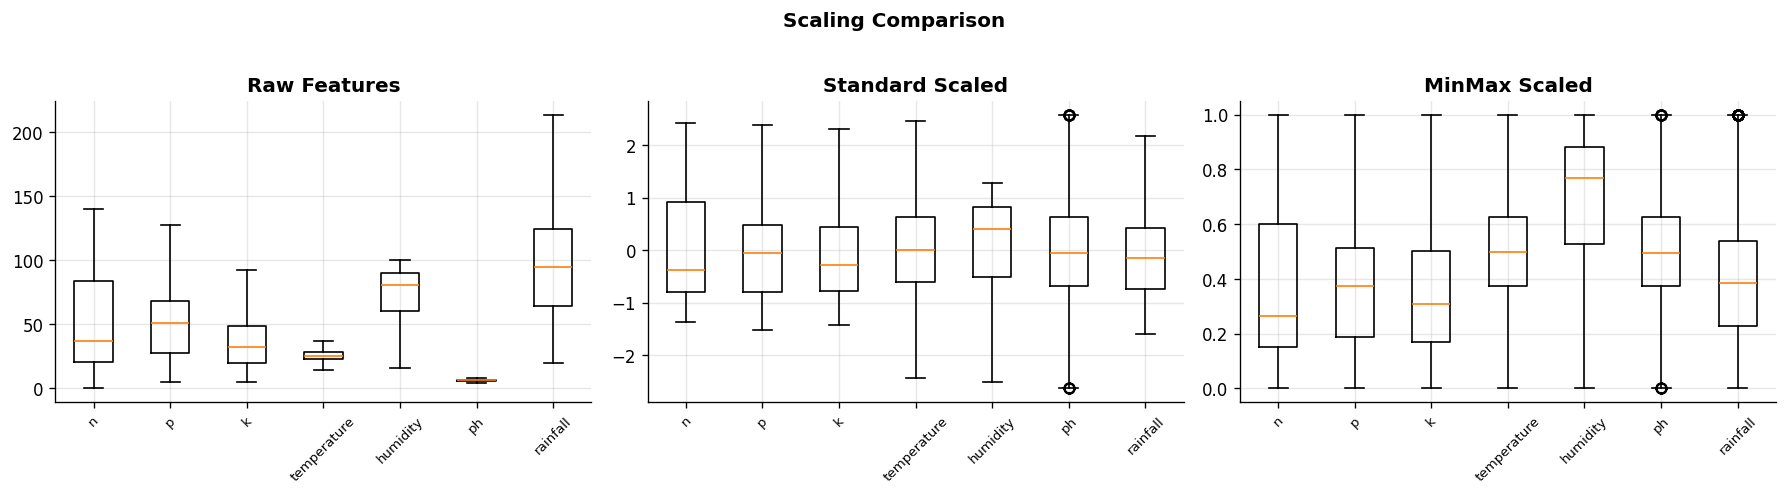

StandardScaler chosen: handles outliers better, required by SVM/KNN.


In [5]:
X = df_clean[ENG_FEATURES].values
y = df_clean['label_enc'].values

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

X_std = scaler_std.fit_transform(X)
X_mm  = scaler_mm.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data_arr, title in zip(axes,
    [X[:, :7], X_std[:, :7], X_mm[:, :7]],
    ['Raw Features', 'Standard Scaled', 'MinMax Scaled']):
    ax.boxplot(data_arr, labels=FEATURES, vert=True)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Scaling Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/phase2_scaling.png', bbox_inches='tight')
plt.show()

print('StandardScaler chosen: handles outliers better, required by SVM/KNN.')

## 2.5  Train / Validation / Test Split

In [6]:
# 70% train, 15% val, 15% test  — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X_std, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train : {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]:4d} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Verify class balance in each split
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    print(f'{split_name} — classes: {len(unique)}, min/max: {counts.min()}/{counts.max()}')

Train : 1540 samples (70%)
Val   :  330 samples (15%)
Test  :  330 samples (15%)
Train — classes: 22, min/max: 70/70
Val — classes: 22, min/max: 15/15
Test — classes: 22, min/max: 15/15


## 2.6  Save Processed Bundle

In [7]:
bundle = {
    'df_clean':      df_clean,
    'features':      FEATURES,
    'eng_features':  ENG_FEATURES,
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'X_raw':   X,  'y_raw': y,
    'X_scaled': X_std,
    'scaler':    scaler_std,
    'le':        le,
    'class_names': list(le.classes_),
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print('processed_data.pkl updated with full preprocessing bundle.')
print(f'Keys: {list(bundle.keys())}')

processed_data.pkl updated with full preprocessing bundle.
Keys: ['df_clean', 'features', 'eng_features', 'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'X_raw', 'y_raw', 'X_scaled', 'scaler', 'le', 'class_names']
